In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# High-Dimensional Linear Regression

Today we shall look at the idea of regularization in the context of regression with many covariates (also known as 'high-dimensional' regression). We work with a very simple dataset to illustrate the key ideas. This simple dataset, which comes from the introductory statistics textbook "Statistical Sleuth" by Ramsey and Schafer,  contains weekly wages in 1987 for a sample of 25437 males between the ages of 18 and 70 who worked full-time along with their years of education, years of experience, indicator variable for whether they worked near a city, and a code for the region in the US where they worked.

In [40]:
#Load the dataset wagedata.csv
dt = pd.read_csv("wagedata.csv")
print(dt.head(10))

      Region   MetropolitanStatus  Exper  Educ  WeeklyEarnings
0      South  NotMetropolitanArea      8    12          859.71
1    Midwest     MetropolitanArea     30    12          786.73
2       West     MetropolitanArea     31    14         1424.50
3       West     MetropolitanArea     17    16          959.16
4       West     MetropolitanArea      6    12          154.32
5    Midwest     MetropolitanArea     24    17          282.19
6  Northeast     MetropolitanArea     14    12          444.44
7  Northeast     MetropolitanArea     28    12          451.09
8      South     MetropolitanArea     40    12          490.27
9      South     MetropolitanArea      7    16          493.83


We shall fit regressions to this dataset using logarithm of weekly earnings as the response variable:
\begin{align*}
   y = \log \left( \text{weekly earnings} \right)
\end{align*}
and years of experience as the covariate: 
\begin{align*}
   x = \text{Exper} = \text{Years of Experience}.
\end{align*}
The following is the scatter plot between $y$ and $x$. 

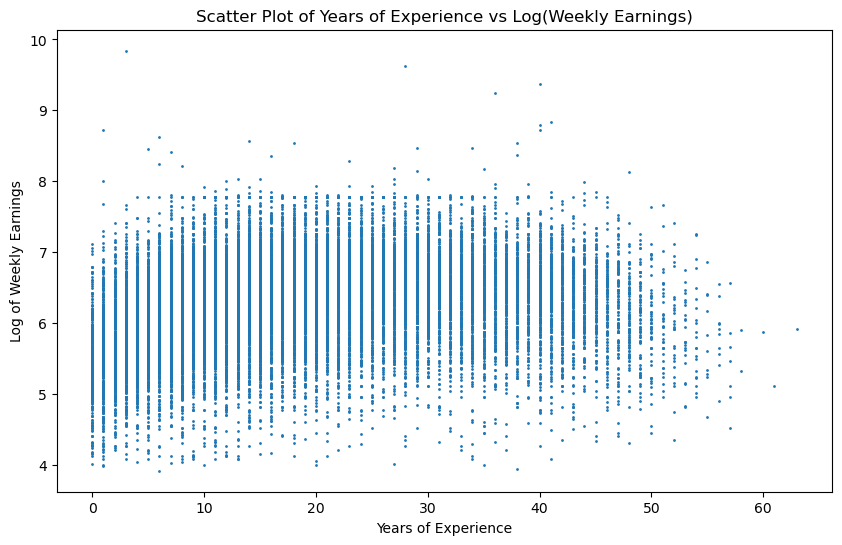

In [41]:
import numpy as np
y = np.log(dt['WeeklyEarnings'])
x = dt['Exper']
import matplotlib.pyplot as plt
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Scatter Plot of Years of Experience vs Log(Weekly Earnings)')
plt.show()

A simple quadratic regression model can be fit to this dataset as: 

                            OLS Regression Results                            
Dep. Variable:         WeeklyEarnings   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     1939.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:52:38   Log-Likelihood:                -22294.
No. Observations:               25437   AIC:                         4.459e+04
Df Residuals:                   25434   BIC:                         4.462e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.6996      0.010    569.429   

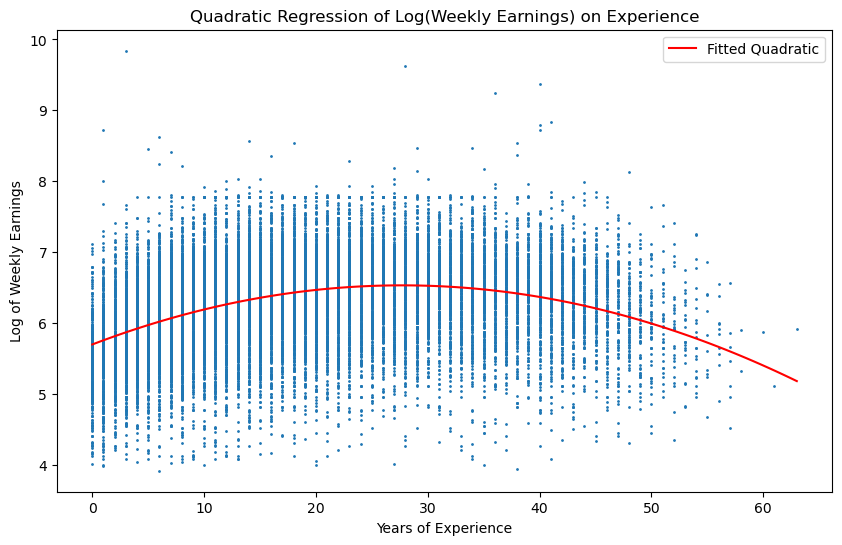

In [42]:
X = sm.add_constant(x)
X['Exper_Square'] = np.square(x)
model_2 = sm.OLS(y, X).fit()

print(model_2.summary())

#Plotting the fitted quadratic on the scatter plot

b0, b1, b2 = model_2.params
x_range = np.linspace(x.min(), x.max(), 100)
fitted_model_2 = b0 + b1*x_range + b2*np.square(x_range)

plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.plot(x_range,fitted_model_2, color = 'red', label = 'Fitted Quadratic')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Quadratic Regression of Log(Weekly Earnings) on Experience')
plt.legend()
plt.show()

## High-dimensional linear regression model

In the last lecture, we motivated the following high-dimensional linear regression model for this dataset. We arrived at this model by considering broken stick regression models and increasing the knots. 

In this dataset, the variable $x$ takes the values $0, 1, \dots, 63$. Considering all these possible knots (with the exception of the last value 63 because $(x - 63)_+$ is always zero) leads us to the model equation:
$$
  y = \beta_0 + \beta_1 x + \beta_2 (x - 1)_+ + \beta_3 (x - 2)_+
  + \dots + \beta_{63}(x - 62)_+ \tag{1}
$$
This is a linear regression
model with $64$ coefficients. The interpretation of the regression
coefficients are as follows. $\beta_0$ is the simply the value of $y = 
\log(\text{Earnings})$ when $x = 0$ (i.e., for someone just joining the
workforce). To obtain the interpretation for $\beta_1$, first plug in
$x = 1$ in the model equation and then $x = 0$ and subtract the second
equation from the first. This gives
\begin{equation*}
  \beta_1 = y_1 - y_0 = \log(E_1) - \log(E_0) =
  \log\left(\frac{E_1}{E_0} \right) \approx \frac{E_1 - E_0}{E_0}. 
\end{equation*}
Here $E_0$ and $E_1$ are Earnings for $x =  0$ and $x = 1$
respectively, and in the last equality, we again used $\log(u) \approx u -
1$ for $u \approx 1$. Thus $100\beta_1$ represents the increment  (in
percent) in salary from year 0 to year 1. For example, $\beta_1 =
0.05$ means that the salary increases by $5\%$ from year 0 to year 1. What is the
interpretation for $\beta_2$? It is easy to see that:
\begin{equation*}
  \log E_2 = \beta_0 + 2 \beta_1 + \beta_2 ~~~ \log E_1 = \beta_0 +
  \beta_1 ~~~ \log E_0 = \beta_0. 
\end{equation*}
Thus
\begin{equation*}
  \beta_2 = \log E_2 - 2 \log E_1 + \log E_0 = \log \frac{E_2}{E_1} -
  \log \frac{E_1}{E_0} \approx \frac{E_2 - E_1}{E_1} - \frac{E_1 -
    E_0}{E_0}. 
\end{equation*}
Thus $100 \beta_2$ represents the change in the percent increment
between years 1 and 2 compared to the percent increment between years
0 and 1. For example, $\beta_2 = 0.0003$ means that the percent
increment decreases by $0.03$ after year 2. If $\beta_1 = 0.05$, we
would have a $5\%$ increment after year 1 and a $5 - 0.03 = 4.97\%$
increment after year 2. More generally, the interpretation for
$\beta_j, j \geq 2$ is as follows: $100\beta_j$ is the change in the
percent increment between years $j-1$ and $j$ compared to the percent
increment between years $j-2$ and $j-1$. For a concrete example,
suppose
\begin{equation*}
  \beta_0 = 5.74 ~~~ \beta_1 = 0.05 ~~~ \beta_2 = -0.0003 ~~~ \beta_3 =
  -0.0008 ~~~ \beta_4 = -0.001 ~~~ \dots
\end{equation*}
then

1. weekly earnings for someone just joining the workforce is
  $\exp(5.74) = \$311.06$, 
2. increment after year 1 is $5 \%$, 
3. increment after year 2 is $(5 - 0.03) = 4.97 \%$,
4. increment after year 3 is $(4.97 - 0.08) = 4.89\%$,
5. increment after year 4 is $(4.89 - 0.1) = 4.79 \%$, and so on. 

If all $\beta_j, j \geq 2$ are negative, then, after a
while, the increments may become negative which means that the salary
actually starts decreasing after a certain number of years of
experience.

The all knots regression model (in equation (1)) can also be fit by the OLS function in statsmodels. However it is usually not a good idea to fit a linear regression model with many covariates using plain old OLS. The reason is that there will be overfitting leading to poor interpretability and poor predictive power. We shall demonstrate this below. 

In [43]:
#Here is how we can use OLS to fit the regression model with all possible knots 1, 2,.., 62.
X = sm.add_constant(x) #adding intercept
for knot in range(1, 63):
    X[f'knot_{knot}'] = np.maximum(x - knot, 0)

model_all_knots = sm.OLS(y, X).fit()
print(model_all_knots.summary())

                            OLS Regression Results                            
Dep. Variable:         WeeklyEarnings   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     67.42
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:52:48   Log-Likelihood:                -22188.
No. Observations:               25437   AIC:                         4.450e+04
Df Residuals:                   25375   BIC:                         4.501e+04
Df Model:                          61                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4711      0.030    185.217      0.0

The main problem with the above OLS output is that the estimated regression coefficients are not interpretable. To see this, note that the fitted coefficients are:
\begin{equation*}
  \beta_0 = 5.4711 ~~~ \beta_1 = 0.1347 ~~~ \beta_2 = 0.0323 ~~~ \beta_3 =
  -0.0847 ~~~ \beta_4 = 0.0185 ~~~ \dots
\end{equation*}
so that the interpretations become

1. weekly earnings for someone just joining the workforce is
  $\exp(5.4711) = \$237.72$, 
2. increment after year 1 is $13.47 \%$, 
3. increment after year 2 is $(13.47 + 3.23) = 16.7 \%$,
4. increment after year 3 is $(16.7 - 8.47) = 8.23\%$,
5. increment after year 4 is $(8.23 + 1.85) = 10.08 \%$, and so on.

Clearly the increments are quite large, and they also oscillate somewhat wildly from year to year. So the fitted model is somewhat nonsensical.

It is also interesting to compare this fitted model to the earlier quadratic model in terms of AIC and BIC. The AIC of this model is actually smaller than that of the quadratic model. However the BIC of this model is larger. Even though, the AIC is smaller, no one would want to use this fitted model because of poor interpretability. One can also plot the fitted function on the scatter plot of the data as shown below. The fitted function is quite wiggly. 


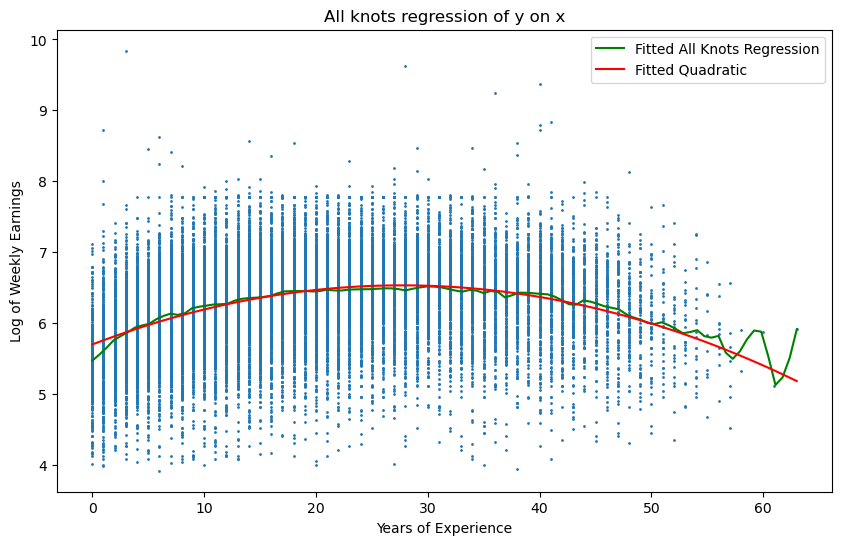

In [44]:
#Plotting the fitted values of this model: 
# Generate x_range for plotting
x_range = np.linspace(x.min(), x.max(), 100)

# Prepare a DataFrame for x_range
X_range = pd.DataFrame({'const': 1, 'x': x_range})
for knot in range(1, 63):
    X_range[f'knot_{knot}'] = np.maximum(X_range['x'] - knot, 0)

fitted_model_all_knots = model_all_knots.predict(X_range)

plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.plot(x_range,fitted_model_all_knots, color = 'green', label = 'Fitted All Knots Regression')
plt.plot(x_range,fitted_model_2, color = 'red', label = 'Fitted Quadratic')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('All knots regression of y on x')
plt.legend()
plt.show()

The reason why this 'all-knots' regression model is giving us a poor fit is not because the model itself is inadequate but it is rather because of the use of OLS to estimate its coefficients. The sample size here is quite large ($n = 25437$). The problem is much worse if the sample size were smaller. To illustrate this, consider fitting this model to a smaller dataset obtained by randomly sampling $n = 500$ observations from the full dataset. This is demonstrated below. 

In [76]:
#Repeating the analysis on a smaller dataset: 
n = 500
random_seed = 42
dt_small = dt.sample(n = 500, random_state = random_seed)
print(dt_small.shape)
print(dt_small.head())
#dt_small = dt #this is to switch back to the full dataset

(500, 5)
          Region   MetropolitanStatus  Exper  Educ  WeeklyEarnings
8735        West     MetropolitanArea     19    14          735.99
13369  Northeast  NotMetropolitanArea     15    16          807.22
5512     Midwest  NotMetropolitanArea     18    16          341.88
24277      South  NotMetropolitanArea     32    12          240.38
24959      South     MetropolitanArea     14    16         1210.83


                            OLS Regression Results                            
Dep. Variable:         WeeklyEarnings   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     55.83
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.34e-22
Time:                        14:02:07   Log-Likelihood:                -405.85
No. Observations:                 500   AIC:                             817.7
Df Residuals:                     497   BIC:                             830.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.6176      0.069     81.159   

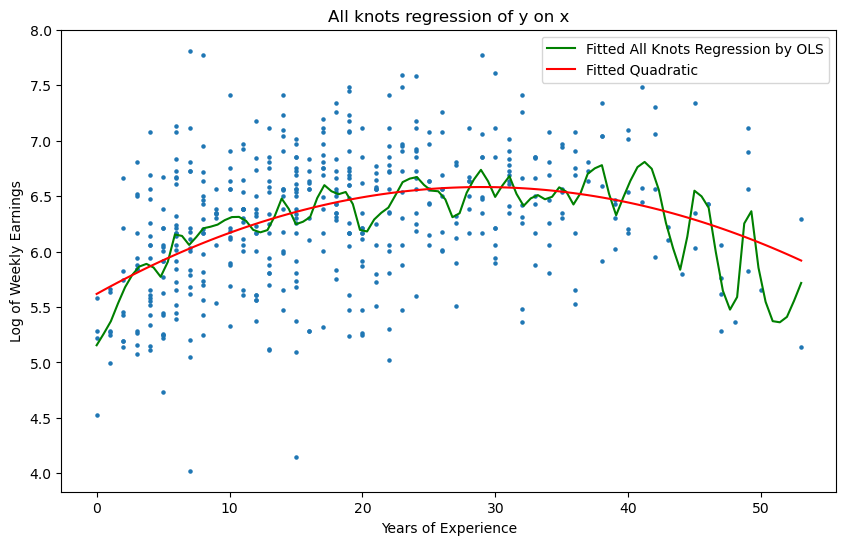

In [77]:
#Let us now repeat the exercise fitting the quadratic model as well as the all-knots regression model on this smaller dataset: 
y = np.log(dt_small['WeeklyEarnings'])
x = dt_small['Exper']

#Quadratic model: 
X = sm.add_constant(x)
X['Exper_Square'] = np.square(x)
model_quad = sm.OLS(y, X).fit()

print(model_quad.summary())

#Plotting the fitted quadratic on the scatter plot
b0, b1, b2 = model_quad.params
x_range = np.linspace(x.min(), x.max(), 100)
fitted_model_quad = b0 + b1*x_range + b2*np.square(x_range)

X_all_knots = sm.add_constant(x) #adding intercept
for knot in range(1, 63):
    X_all_knots[f'knot_{knot}'] = np.maximum(x - knot, 0)
model_all_knots = sm.OLS(y, X_all_knots).fit()

print(model_all_knots.summary())

# Prepare a DataFrame for x_range
X_range = pd.DataFrame({'const': 1, 'x': x_range})
for knot in range(1, 63):
    X_range[f'knot_{knot}'] = np.maximum(X_range['x'] - knot, 0)

fitted_model_all_knots = model_all_knots.predict(X_range)

plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
plt.plot(x_range,fitted_model_all_knots, color = 'green', label = 'Fitted All Knots Regression by OLS')
plt.plot(x_range,fitted_model_quad, color = 'red', label = 'Fitted Quadratic')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('All knots regression of y on x')
plt.legend()
plt.show()

Now the coefficients oscillate even more wildly to make interpretation fully nonsensical. Indeed now
\begin{equation*}
  \beta_0 = 5.1547 ~~~ \beta_1 = 0.1953 ~~~ \beta_2 = 0.1042 ~~~ \beta_3 =
  -0.0938 ~~~ \beta_4 = -0.1610 ~~~ \dots
\end{equation*}
so that the interpretations become

1. weekly earnings for someone just joining the workforce is
  $\exp(5.4711) = \$173.24$, 
2. increment after year 1 is $19.53 \%$, 
3. increment after year 2 is $(19.53 + 10.42) = 29.95 \%$,
4. increment after year 3 is $(29.95 - 9.38) = 20.57\%$,
5. increment after year 4 is $(20.57 - 16.10) = 4.47 \%$, and so on.

Clearly these numbers are meaningless. Moreover the AIC and BIC now are both larger than that of the quadratic model. In situations such as this where the OLS is giving meaningless results, one uses regularization.

## Regularization via Bayesian Inference

We work with the following prior:
\begin{align*}
   \beta_0, \beta_1 \overset{\text{i.i.d}}{\sim} \text{unif}(-C, C) ~~~ \beta_2, \dots, \beta_{m} \overset{\text{i.i.d}}{\sim} N(0, \gamma^2 \sigma^2)
\end{align*}
We treat $\gamma$ and $\sigma$ also as unknown parameters and assign the prior: 
\begin{align*}
    \log \gamma, \log \sigma \overset{\text{i.i.d}}{\sim} \text{unif}(-C, C). 
\end{align*}
In the last lecture, we discussed the prior $\log \tau, \log \sigma \overset{\text{i.i.d}}{\sim} \text{unif}(-C, C)$. 

The only difference between this prior and the prior used in the last lecture is that we are now parametrizing in terms of $(\gamma, \sigma)$ as opposed to $(\tau, \sigma)$ (the connection is $\tau = \sigma \gamma$). This is strictly a different prior however because under the assumption $\log \gamma, \log \sigma \overset{\text{i.i.d}}{\sim} \text{unif}(-C, C)$, the parameters $\gamma \times \sigma$ and $\sigma$ become dependent (under the prior) but the previous model assumes prior independence of $\tau$ and $\sigma$. 

The posterior of $\gamma, \sigma, \beta$ can be described as follows. 


The posterior of $\beta$ conditional on $\sigma$ and $\gamma$ is given by: 
\begin{align*}
   \beta \mid \text{data}, \sigma, \tau \sim N \left(\left(\frac{X^T
                          X}{\sigma^2} + Q^{-1}  \right)^{-1} \frac{X^T y}{\sigma^2},  \left(\frac{X^T X}{\sigma^2} + Q^{-1} \right)^{-1}\right). 
\end{align*}
where $Q$ is the diagonal matrix with diagonal entries $C, C, \gamma^2\sigma^2, \dots, \gamma^2\sigma^2$. We use the approximation: 
\begin{align*}
   Q^{-1} = \text{diag}(1/C, 1/C, 1/\tau^2, \dots, 1/\tau^2) \approx \text{diag}(0, 0, 1/\tau^2, \dots, 1/\tau^2) = \frac{J}{\tau^2}
\end{align*}
where $J$ is the diagonal matrix with diagonals $0, 0, 1, \dots, 1$. 


The posterior mean of $\beta$ given $\sigma, \tau$ is 
\begin{align*}
   \mathbb{E}(\beta \mid \text{data}, \sigma, \gamma) = \left(\frac{X^T X}{\sigma^2} + \frac{J}{\sigma^2 \gamma^2} \right)^{-1} \frac{X^T y} {\sigma^2} = \left(X^T X + \frac{J}{\gamma^2} \right)^{-1} X^T y
\end{align*}
This only depends on $\gamma$. The above can be viewed as ridge regularization with penalty $\lambda = 1/\gamma^2$. 

The $X$ matrix in this high-dimensional linear regression is the following. 

In [78]:
X = X_all_knots.to_numpy()
print(X.shape)
m = 63 #the parameters are b_0, \dots, b_m

(500, 64)


Given a value of $\gamma$, the posterior mean estimate of $\beta$ is computed below. It is identical to ridge regression with $\lambda = 1/\gamma^2$. 

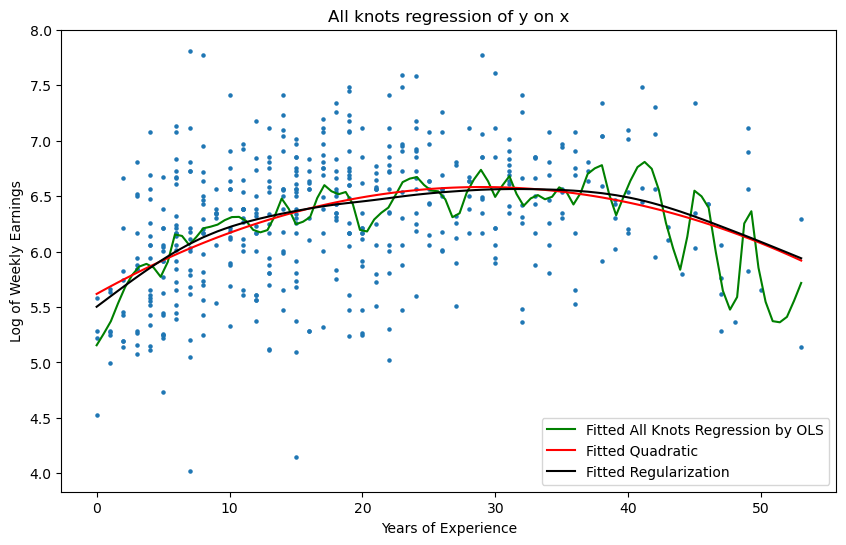

In [79]:
gamma_value = 0.0001
gamma_value = 0.0223
J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma_value**(-2), m-1)])) 
Mat =  X.T @ X + J_by_gammasq
Matinv = np.linalg.inv(Mat)
betahat_gamma = Matinv @ X.T @ y.to_numpy().reshape(-1, 1)

#calculating the fitted values for a grid of x-values:
x_range = np.linspace(x.min(), x.max(), 100)

X_range = pd.DataFrame({'const': 1, 'x': x_range})
kmax = m-1
for knot in range(1, (1 + kmax)):
    X_range[f'knot_{knot}'] = np.maximum(x_range - knot, 0)

fitted_model_postmean_gamma = X_range.values @ betahat_gamma

plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
plt.plot(x_range,fitted_model_all_knots, color = 'green', label = 'Fitted All Knots Regression by OLS')
plt.plot(x_range,fitted_model_quad, color = 'red', label = 'Fitted Quadratic')
plt.plot(x_range,fitted_model_postmean_gamma, color = 'black', label = 'Fitted Regularization')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('All knots regression of y on x')
plt.legend()
plt.show()



We next describe the posterior of $\gamma$ and $\sigma$. Unlike the case of the previous prior, the posterior of $\sigma$ conditional on $\gamma$ can be described in closed form as: 

 \begin{equation*}
   \frac{1}{\sigma^2} \mid \text{data}, \gamma \sim \text{Gamma} \left(\frac{n}{2} - 1, \frac{y^T y - y^T X (X^T X + \gamma^{-2} J)^{-1} X^T y}{2} \right) 
 \end{equation*}
 Finally the posterior of $\gamma$ is given by: 

 \begin{align*}
   \gamma \mid \text{data} \sim \gamma^{-n+1} \sqrt{\det (X^T X + \gamma^{-2} J)^{-1}} \left(\frac{1}{y^T y - y^T X (X^T X + \gamma^{-2} J)^{-1} X^T y} \right)^{(n/2) - 1}
 \end{align*}

 We can compute this posterior on a grid of $\gamma$ values. Now we only need a 1D grid for $\gamma$ (unlike the previous model, where we needed two grids for $\tau$ and $\sigma$). 

In [80]:
gamma_gr = np.logspace(np.log10(1e-6), np.log10(1e4), 2000)
logpost_gamma = np.zeros(len(gamma_gr))

for i in range(len(gamma_gr)):
    gamma = gamma_gr[i]
    J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), m-1)])) 
    Mat =  X.T @ X + J_by_gammasq
    Matinv = np.linalg.inv(Mat)
    sgn, logcovdet = np.linalg.slogdet(Matinv)
    logpost_gamma[i] =(-m)*np.log(gamma) + 0.5 * logcovdet - (n/2 - 1)*np.log(y.T @ y - y.T @ X @ Matinv @ X.T @ y)


Below we compute the posterior of $\gamma$ (correctly normalized) as well as the posterior mean. 

In [ ]:
post_gamma  = np.exp(logpost_gamma - np.max(logpost_gamma))
post_gamma = post_gamma/np.sum(post_gamma)
postmean_gamma = np.sum(gamma_gr * post_gamma)
print(postmean_gamma)
print(1/(postmean_gamma ** 2)) #this is lambda = 1/gamma^2

0.022375927631204152
1997.2751679918663


Below we plot the posterior of $\gamma$ as a function of $\gamma$. The x-axis is on the log-scale. 

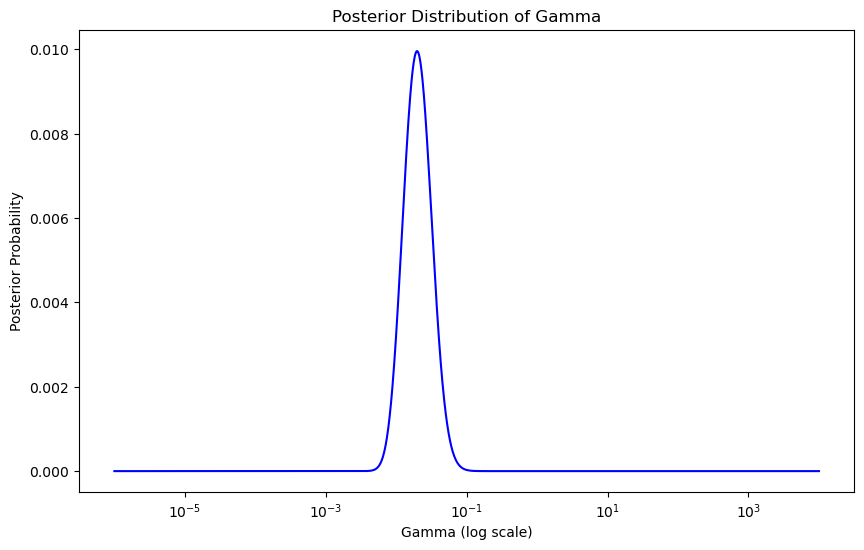

In [83]:
#Plotting post_gamma as a function of gamma:
plt.figure(figsize = (10, 6))
plt.plot(gamma_gr, post_gamma, color = 'blue')
plt.xscale('log')
plt.xlabel('Gamma (log scale)')
plt.ylabel('Posterior Probability')
plt.title('Posterior Distribution of Gamma')
plt.show()

Clearly, there is a single well-defined peak in this posterior distribution for $\gamma$. This means that the model is preferring a specific value of $\gamma$ that is neither too big nor too small. We can create samples from this posterior of $\gamma$ by simply sampling from the discretized distribution. 

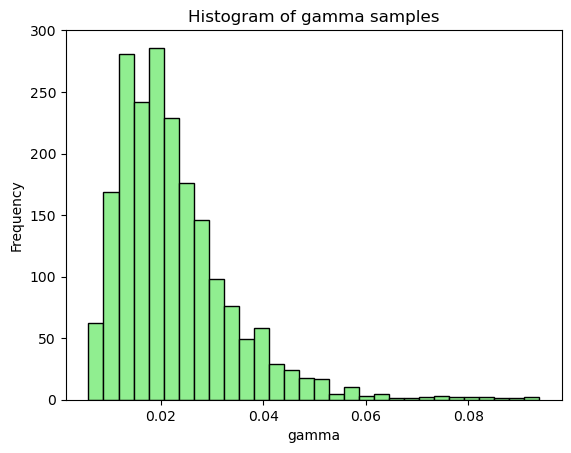

In [84]:
N = 2000
gamma_samples = np.random.choice(gamma_gr, size=N, p=post_gamma, replace=True)
plt.hist(gamma_samples, bins=30, color='lightgreen', edgecolor='black')
plt.title('Histogram of gamma samples')
plt.xlabel('gamma')
plt.ylabel('Frequency')
plt.show()

Using the samples of $\gamma$, samples from $\beta$ and $\sigma$ can be constructed as follows. 

In [85]:
sig_samples = np.zeros(N)
betahats = np.zeros((m+1, N))
for i in range(N):
    gamma = gamma_samples[i]
    J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), m-1)])) 
    Mat =  X.T @ X + J_by_gammasq
    Matinv = np.linalg.inv(Mat)
    gamma_dist_lambda_parameter = (y.T @ y - y.T @ X @ Matinv @ X.T @ y)/2
    gamma_dist_alpha_parameter = n/2 - 1
    sig = np.sqrt(1/np.random.gamma(gamma_dist_alpha_parameter, 1/gamma_dist_lambda_parameter))
    sig_samples[i] = sig
    XTX = np.dot(X.T, X)
    TempMat = np.linalg.inv((J_by_gammasq/(sig ** 2)) + (XTX/(sig ** 2)))
    XTy = np.dot(X.T, y)
    #generate betahat from the normal distribution with mean: 
    norm_mean = np.dot(TempMat, XTy/(sig ** 2)) 
    #and covariance matrix: 
    norm_cov = TempMat  
    betahat = np.random.multivariate_normal(norm_mean, norm_cov)
    betahats[:,i] = betahat
    

The overall estimate of $\beta$ can be obtained by taking the mean of the individual $\beta$ samples. This is the posterior mean estimate of $\beta$ in the full Bayesian model. 

In [86]:
beta_est = np.mean(betahats, axis = 1)


Below we plot the fitted values corresponding to the posterior mean estimate of $\beta$. 

In [87]:
#calculating the fitted values for a grid of x-values:
x_range = np.linspace(x.min(), x.max(), 100)

X_range = pd.DataFrame({'const': 1, 'x': x_range})
for knot in range(1, (1 + kmax)):
    X_range[f'knot_{knot}'] = np.maximum(x_range - knot, 0)

fitted_model_postmean_fullmodel = X_range.values @ beta_est



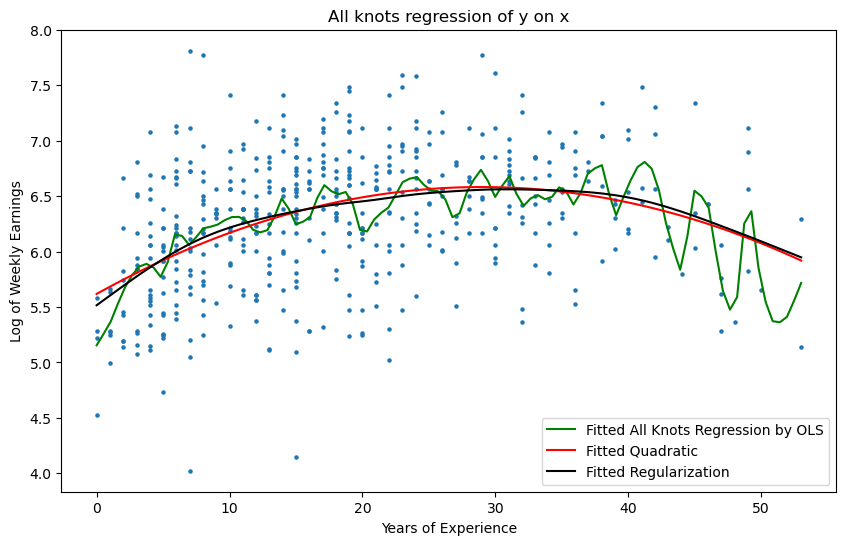

In [88]:
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
plt.plot(x_range,fitted_model_all_knots, color = 'green', label = 'Fitted All Knots Regression by OLS')
plt.plot(x_range,fitted_model_quad, color = 'red', label = 'Fitted Quadratic')
plt.plot(x_range,fitted_model_postmean_fullmodel, color = 'black', label = 'Fitted Regularization')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('All knots regression of y on x')
plt.legend()
plt.show()

It is interesting that the posterior mean estimate of $\beta$ corresponds to a smooth estimate of the underlying regression curve. 

Below we plot the individual curves coming from posterior samples of $\beta$. This gives an idea of the uncertainty associated with the fitted regression function. 

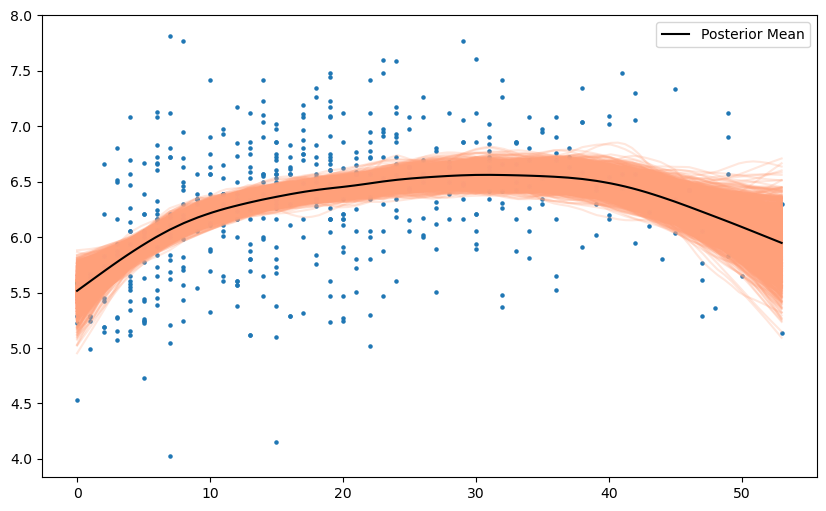

In [89]:
#Plotting all the posterior fitted values: 
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
for i in range(N):
    fitted_model_postdraw = X_range.values @ betahats[:,i]
    plt.plot(x_range, fitted_model_postdraw, color = 'lightsalmon', alpha = 0.25)
plt.plot(x_range, fitted_model_postmean_fullmodel, color = 'black', label = 'Posterior Mean')
plt.legend()
plt.show()


It is interesting that the uncertainty bands get wider near the end of the dataset where the data is sparse. Go back and repeat the analysis on the whole dataset (as opposed to the sample dataset of smaller size 500).